In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
df = pd.read_excel('data/n_shot_mean_results.xlsx', index_col=0)

In [3]:
new_order = ['1_shot', '2_shot', '3_shot', '4_shot', '5_shot','5_shot_min', '5_shot_best', '5_shot_max']
df = df.reindex(new_order)

# Speichern der geänderten DataFrame in die gleiche Excel-Datei
#df.to_excel('data/n_shot_mean_results.xlsx')

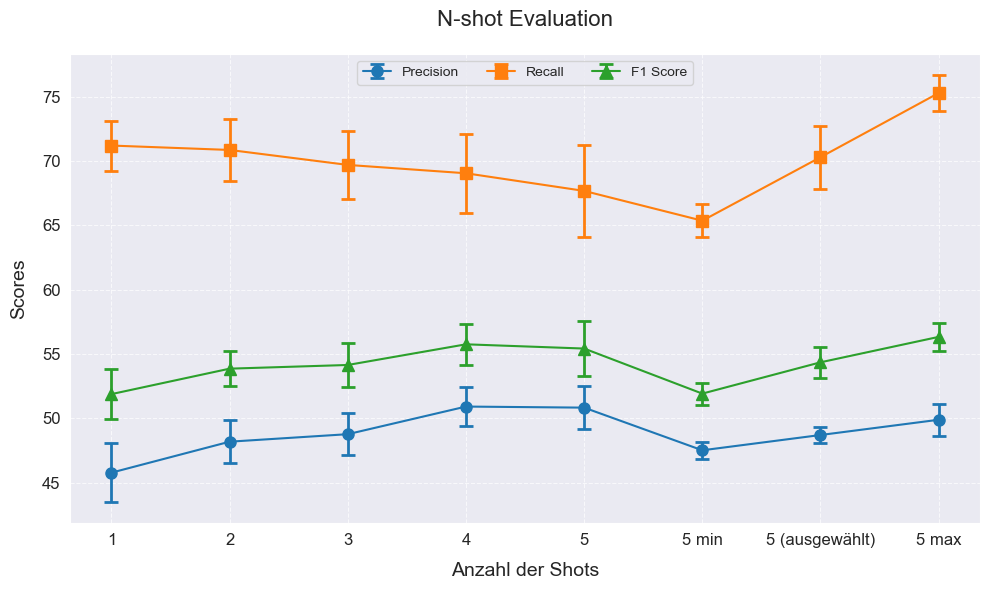

In [4]:
shots = df.index.str.extract(r'(\d+)').astype(int).values.flatten()
shots[df.index == '5_shot_min'] = 6
shots[df.index == '5_shot_best'] = 7
shots[df.index == '5_shot_max'] = 8


average_precision = df['average_precision']
average_recall = df['average_recall']
average_f1 = df['average_f1']
std_precision = df['std_precision']
std_recall = df['std_recall']
std_f1 = df['std_f1']

plt.figure(figsize=(10, 6))

plt.errorbar(shots, average_precision, yerr=std_precision, label='Precision', fmt='-o', capsize=5, capthick=2, elinewidth=2, markersize=8)
plt.errorbar(shots, average_recall, yerr=std_recall, label='Recall', fmt='-s', capsize=5, capthick=2, elinewidth=2, markersize=8)
plt.errorbar(shots, average_f1, yerr=std_f1, label='F1 Score', fmt='-^', capsize=5, capthick=2, elinewidth=2, markersize=8)

plt.xlabel('Anzahl der Shots', fontsize=14, labelpad=10)
plt.ylabel('Scores', fontsize=14, labelpad=10)
plt.title('N-shot Evaluation', fontsize=16, pad=20)

plt.legend(fontsize=10, loc='upper center', ncol=3)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks([1, 2, 3, 4, 5, 6, 7, 8], ['1', '2', '3', '4', '5', '5 min', '5 (ausgewählt)', '5 max'], fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

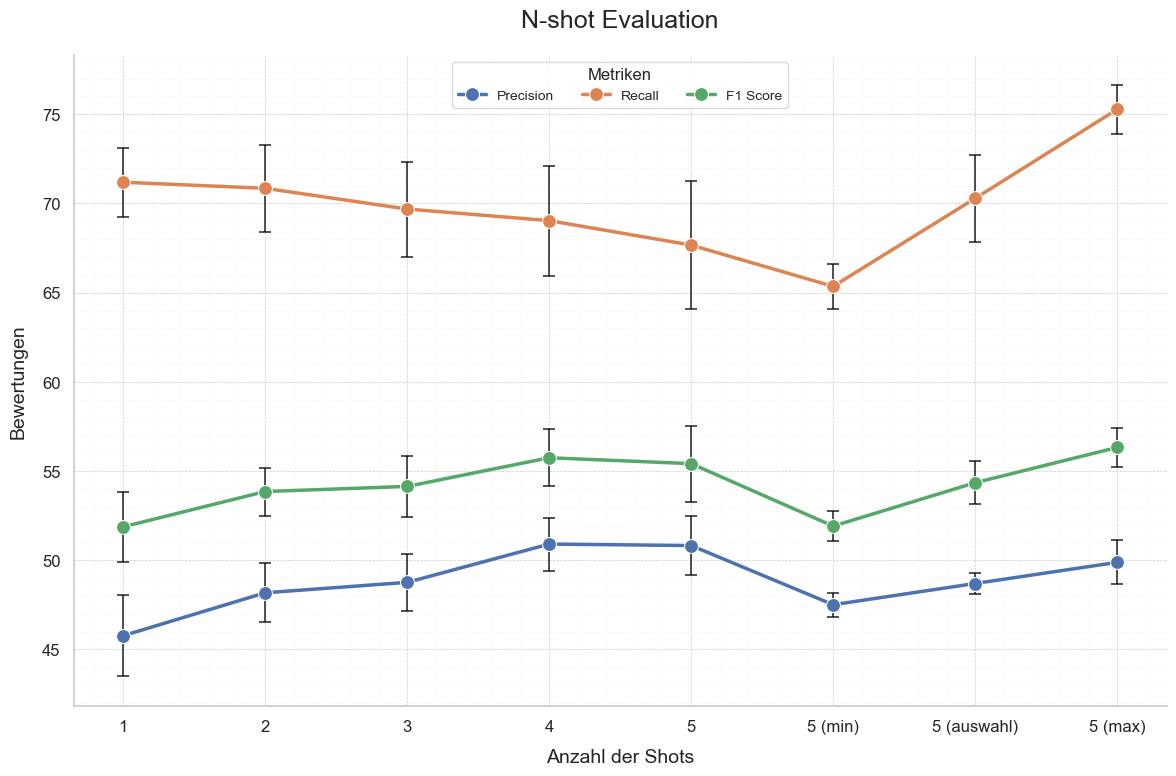

In [5]:
shots = df.index.str.extract(r'(\d+)').astype(int).values.flatten()
shots[df.index == '5_shot_min'] = 6
shots[df.index == '5_shot_best'] = 7
shots[df.index == '5_shot_max'] = 8

plot_data = pd.DataFrame({
    'Shots': np.tile(shots, 3),
    'Score': pd.concat([df['average_precision'], df['average_recall'], df['average_f1']]),
    'Metric': ['Precision']*len(shots) + ['Recall']*len(shots) + ['F1 Score']*len(shots),
    'Error': pd.concat([df['std_precision'], df['std_recall'], df['std_f1']])
})

sns.set_theme(style="whitegrid", palette="deep", font="sans-serif")
sns.set_context("notebook", font_scale=1.2, rc={"lines.linewidth": 2.5})

fig, ax = plt.subplots(figsize=(12, 8))
ax.grid(which='major', color='#CCCCCC', linestyle='--', linewidth=0.5, zorder=0)
ax.grid(which='minor', color='#EEEEEE', linestyle=':', linewidth=0.5, zorder=0)
ax.minorticks_on()
for metric in ['Precision', 'Recall', 'F1 Score']:
    metric_data = plot_data[plot_data['Metric'] == metric]
    ax.errorbar(metric_data['Shots'], metric_data['Score'],
                yerr=metric_data['Error'], fmt='none', capsize=4, capthick=1.2,
                elinewidth=1.2, alpha=0.8, color='black', zorder=1)

sns.lineplot(ax=ax, x='Shots', y='Score', hue='Metric', data=plot_data,
             marker='o', markersize=10, errorbar=None, zorder=2)

ax.set_xlabel('Anzahl der Shots', fontsize=14, labelpad=10)
ax.set_ylabel('Bewertungen', fontsize=14, labelpad=10)
ax.set_title('n-shot Evaluation', fontsize=18, pad=20)

ax.set_xticks([1, 2, 3, 4, 5, 6, 7, 8])
ax.set_xticklabels(['1', '2', '3', '4', '5', '5 (min)', '5 (auswahl)', '5 (max)'])
ax.tick_params(axis='both', which='major', labelsize=12, width=1.5, length=6)
ax.tick_params(axis='both', which='minor', width=1, length=3)
ax.tick_params(axis='y', labelsize=12)

legend = ax.legend(title='Metriken', fontsize=10, title_fontsize=12, loc='upper center', ncol=3, frameon=True)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_edgecolor('lightgray')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('pics/n_shot.png', bbox_inches='tight')
plt.show()

In [7]:
df

,average_precision,average_recall,average_f1,std_precision,std_recall,std_f1,average_missing_percentage,average_excess_percentage,std_missing_percentage,std_excess_percentage
1_shot,45.770369,71.192613,51.874814,2.278466,1.941899,1.956848,7.062117,3.056709,0.528631,0.541475
2_shot,48.177021,70.850475,53.852775,1.660404,2.435999,1.344925,6.242334,2.313799,0.442811,0.427438
3_shot,48.760490,69.687347,54.138691,1.614917,2.664760,1.721368,5.782268,2.037437,0.702866,0.482645
4_shot,50.906545,69.038797,55.744989,1.483357,3.087549,1.606531,5.298909,1.669774,0.506438,0.385128
5_shot,50.823441,67.667144,55.415347,1.648533,3.598796,2.135186,5.161387,1.578035,0.625588,0.350111
5_shot_min,47.507897,65.352046,51.913232,0.669998,1.282849,0.862035,5.336477,1.565736,0.220603,0.273327
5_shot_best,48.695756,70.285573,54.345332,0.590127,2.457368,1.205345,5.351211,3.175001,0.520886,1.498570
5_shot_max,49.881266,75.274303,56.322049,1.225904,1.392212,1.101295,5.382675,2.285723,0.327335,0.237501


ValueError: The number of FixedLocator locations (8), usually from a call to set_ticks, does not match the number of labels (6).

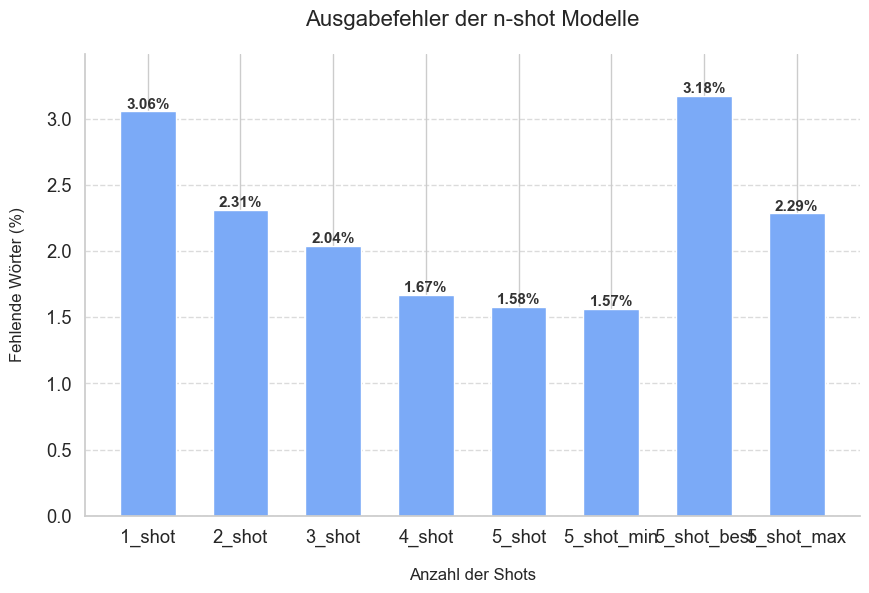

In [8]:
shots = df.index
values = df['average_excess_percentage']

fig, ax = plt.subplots(figsize=(10, 6))

# Hellere Farbe für die Balken
bars = ax.bar(shots, values, color='#7BAAF7', width=0.6)

ax.set_ylabel('Fehlende Wörter (%)', fontsize=12, labelpad=15)
ax.set_xlabel('Anzahl der Shots', fontsize=12, labelpad=15)
ax.set_title('Ausgabefehler der n-shot Modelle', fontsize=16, pad=20)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_ylim(0, max(values) * 1.1)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

# Verbesserte Lesbarkeit der Prozentzahlen
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}%',
            ha='center', va='bottom', fontsize=11, fontweight='bold', color='#333333')

# Anpassen der x-Achse
ax.set_xticks(range(len(shots)))
ax.set_xticklabels(['1', '2', '3', '4', '5', '5 (ausgewählt)'])
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig('pics/missing_pct.png', bbox_inches='tight')
plt.show()